# Introduction to Convolution and Filters

Image processing presents several challenges for algorithms that humans solve effortlessly. Key difficulties include:

- **Viewpoint variation:** Objects appear in different orientations relative to the camera, complicating recognition. For example, a cat facing left versus right looks quite different to a machine.
- **Scale variation:** Objects vary in size depending on their distance from the camera, like a dog seen up close or far away.
- **Illumination conditions:** Changes in lighting can distort colors and shadows, making consistent detection difficult.
- **Background clutter:** Diverse and distracting backgrounds can hide or confuse the object of interest.

While multilayer perceptrons (MLPs) can learn complex functions, their architectures do not leverage **spatial structure in images, limiting their success in vision tasks**. CNNs, designed inspired by the animal visual system, **use convolution and pooling to exploit locality and compositionality.** This architectural inductive bias enables CNNs to excel at image processing.

The term **Convolutional Neural Networks**, which we use today, was used by `Yann LeCun et al`. in their **architecture of LeNet** for the task of recognizing handwritten digits.

## Convolution

### What is a Convolution?

**It is not as complicated as the term might suggest.**

In simple terms, **a convolution involves two matrices of the same or compatible sizes**. The steps are:

1. Multiply the two matrices element-wise (i.e., each corresponding value multiplied together).
2. Sum all those multiplied values to produce one number.

This operation is repeated as a small matrix called a **kernel** or **filter** slides over different regions of an input image, producing a new matrix called a **feature map** or **convolved output**.
- A kernel (small matrix) slides over the input image. At each position, the kernel multiplies element-wise with the overlapping pixels of the image. The products are summed to produce one value in the output feature map.
- This process is **repeated across all spatial locations, creating a transformed representation highlighting specific features.**

**This operation is vital because**
- it reduces the number of trainable parameters compared to fully connected layers,
- it preserves spatial relationships, and
- it enables hierarchical feature extraction in CNNs.



In [ ]:
import numpy as np

In [ ]:
array = np.full((6, 6), fill_value = 20)
array

array([[20, 20, 20, 20, 20, 20],
       [20, 20, 20, 20, 20, 20],
       [20, 20, 20, 20, 20, 20],
       [20, 20, 20, 20, 20, 20],
       [20, 20, 20, 20, 20, 20],
       [20, 20, 20, 20, 20, 20]])

In [ ]:
array[:, 3:] = 10

In [ ]:
array

array([[20, 20, 20, 10, 10, 10],
       [20, 20, 20, 10, 10, 10],
       [20, 20, 20, 10, 10, 10],
       [20, 20, 20, 10, 10, 10],
       [20, 20, 20, 10, 10, 10],
       [20, 20, 20, 10, 10, 10]])

In [ ]:
import matplotlib.pyplot as plt

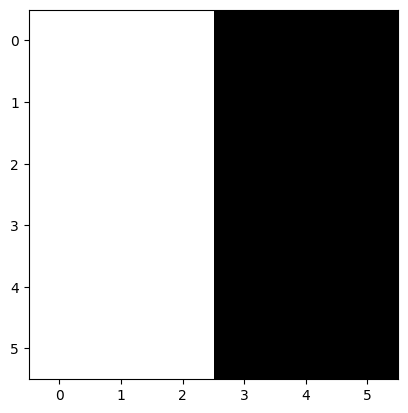

In [ ]:
plt.imshow(array, cmap = 'gray')

In [ ]:
array2 = np.full((4, 4), fill_value = -30)
array2

array([[-30, -30, -30, -30],
       [-30, -30, -30, -30],
       [-30, -30, -30, -30],
       [-30, -30, -30, -30]])

In [ ]:
array2[:, 0::3] = 0

In [ ]:
array2

array([[  0, -30, -30,   0],
       [  0, -30, -30,   0],
       [  0, -30, -30,   0],
       [  0, -30, -30,   0]])

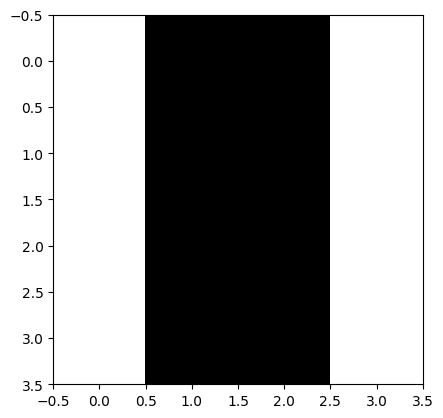

In [ ]:
plt.imshow(array2, cmap = 'gray')

### Convolution vs Cross Correlation

[Article: Visualization](https://glassboxmedicine.com/2019/07/26/convolution-vs-cross-correlation/)

- Both convolution and cross-correlation involve sliding a kernel (filter) over an image and computing values at every location.
- **In deep learning/CNNs:** Although the operation is called **convolution**, modern deep learning libraries typically implement **cross-correlation**.
  - This choice does not affect the performance because during training the network learns filter weights that compensate for the lack of flipping.
- **Convolution** of an image $I$ with a kernel $K$ is defined as:  
$$
S(i, j) = (I * K)(i, j) = \sum_m \sum_n I(i - m, j - n) \cdot K(m, n)
$$
Here, the kernel $K$ is **flipped both horizontally and vertically** before being applied to the image.

- **Cross-correlation** is defined as:  
$$
S(i, j) = (I \star K)(i, j) = \sum_m \sum_n I(i + m, j + n) \cdot K(m, n)
$$
The kernel $K$ is used **as-is, without flipping**.
- **Observations:**
  - **Kernel flipping:** Convolution flips the kernel; cross-correlation does not.

  - **Computation:** Cross-correlation is computationally simpler because it does not require flipping the kernel.

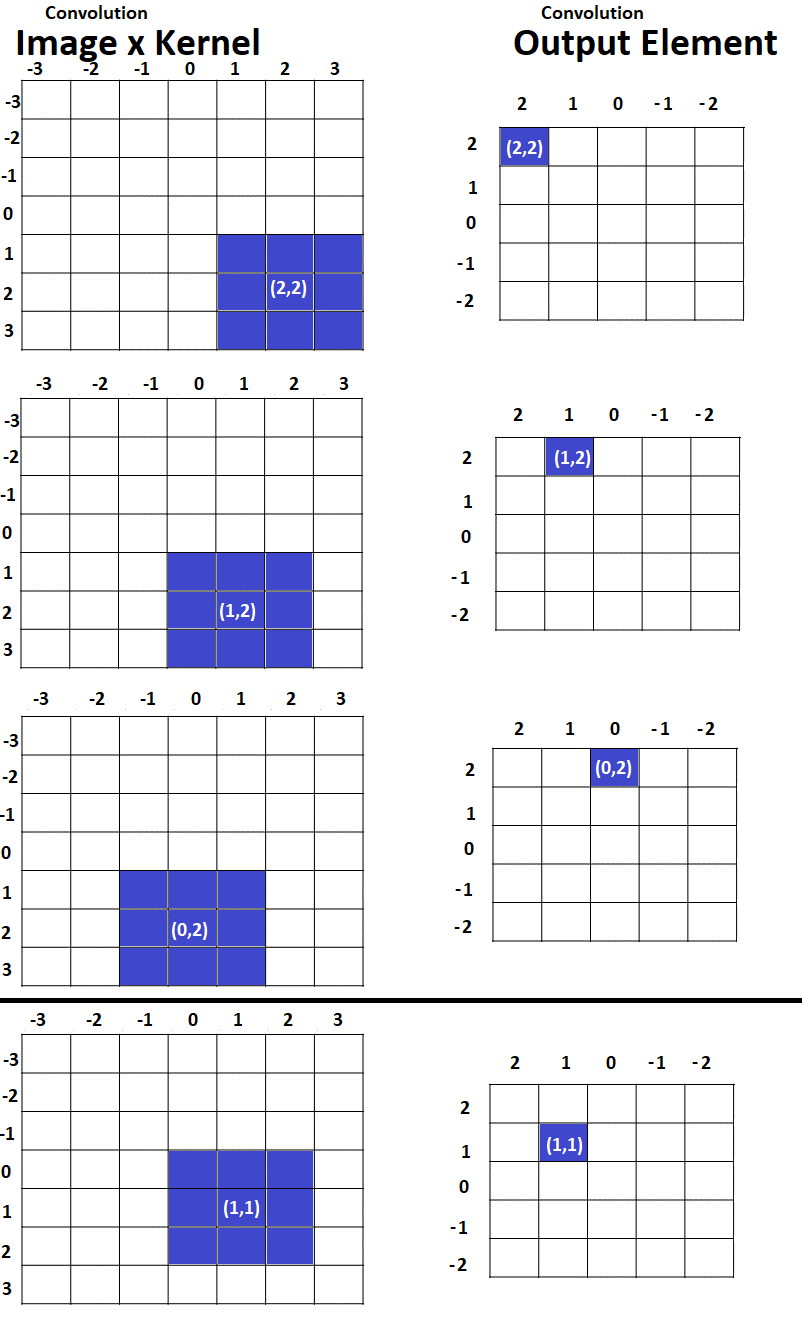

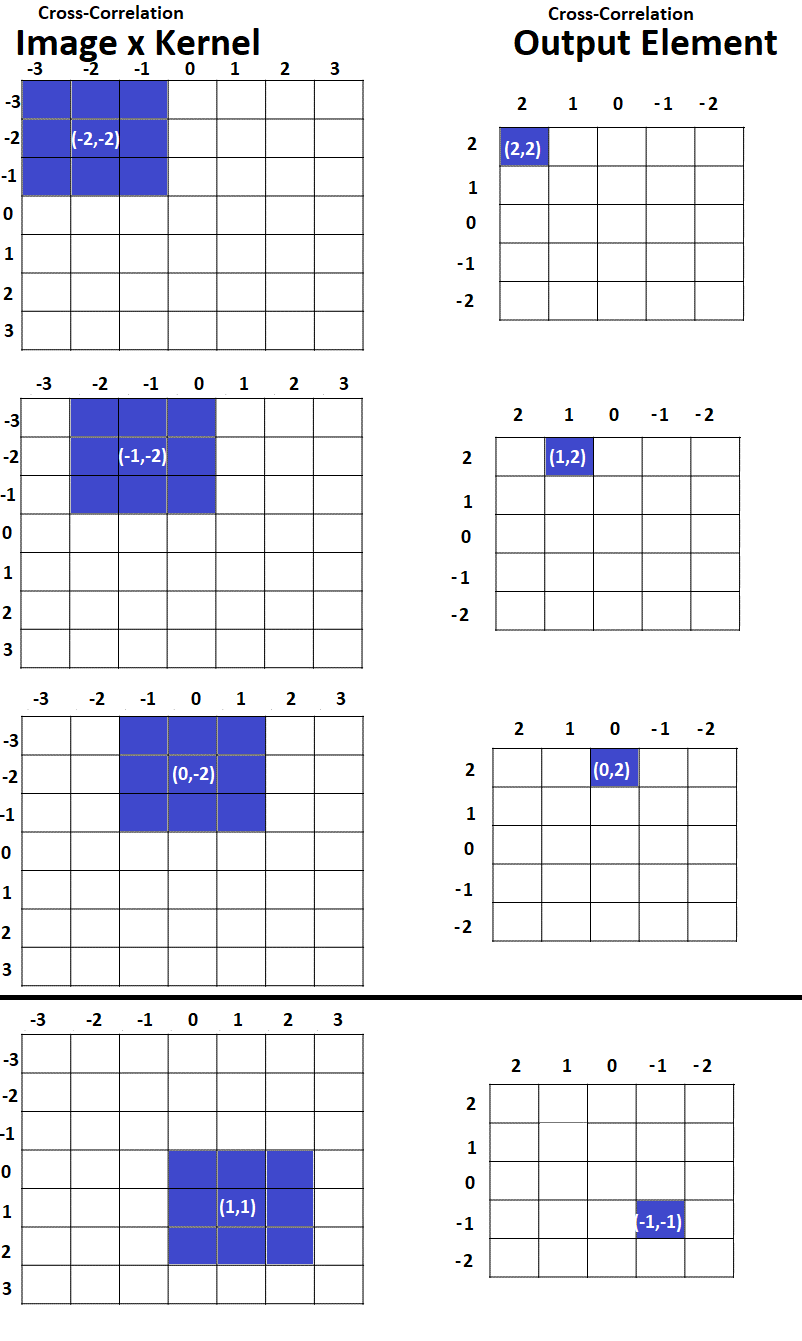

##### **Why flipping matters mathematically?**

  Flipping the kernel maintains theoretical properties of convolution (like associativity). However, in practice for feature extraction in images, it does not significantly change results since filters are learned.


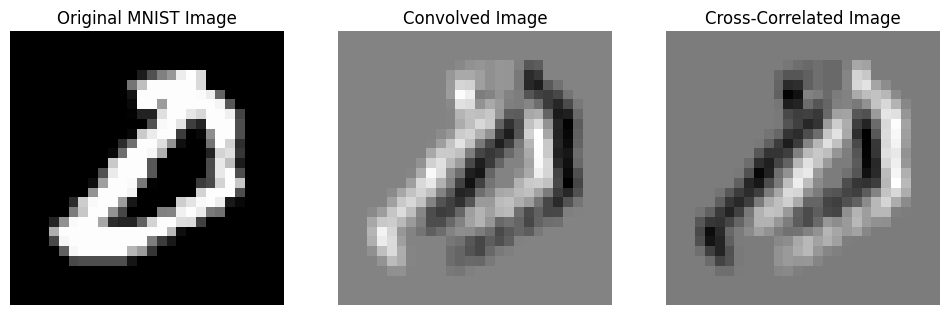

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d, correlate2d
from sklearn.datasets import fetch_openml

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
images = mnist.data.values.reshape(-1, 28, 28)

# Randomly select one image
np.random.seed(42)
index = np.random.randint(0, len(images))
img = images[index]

# Define a simple kernel (Sobel-like edge detector)
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

# Apply convolution
convolved = convolve2d(img, kernel, mode='same', boundary='fill', fillvalue=0)

# Apply cross-correlation
cross_correlated = correlate2d(img, kernel, mode='same', boundary='fill', fillvalue=0)

# Plot original and processed images side by side
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Original MNIST Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Convolved Image')
plt.imshow(convolved, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Cross-Correlated Image')
plt.imshow(cross_correlated, cmap='gray')
plt.axis('off')

plt.show()


### Why use convolution?

Images can be represented as multidimensional arrays with width, height, and depth (channels).
- Traditional **image processing uses small handcrafted filters or kernels** — small matrices designed to perform operations such as blurring, sharpening, or edge detection.
- These **fixed kernels** slide over the large image matrix, **applying mathematical operations (convolutions) at every location**.
- **Image processing:** Common operations such as blurring, smoothing, edge detection, and sharpening are performed through convolutions.
- **Deep learning:** CNNs use convolutional layers to automatically learn filters that detect meaningful patterns like edges, shapes, textures, and more complex features as the network deepens.

### How convolution works in deep learning?

Convolutional Neural Networks (CNNs) **automatically learn these filters from data** during training. Rather than manually specifying kernels, CNNs learn small sets of filter weights that capture important visual patterns relevant to the task.

- The input image is transformed through multiple convolutional layers, each applying a collection of learned kernels.
- Each kernel extracts different features—edges, textures, shapes—that are combined and refined across layers.
- This **automated feature extraction** replaces hand-engineered filters and enables the network to discover rich hierarchical representations.
- Learned kernels adapt to the specific dataset and task, resulting in markedly improved accuracy and generalizability.

## Kernel or Filter

An image can be represented as a multidimensional matrix with width, height, and depth (channels). A **kernel** also called a **convolutional matrix** is a much smaller matrix compared to the original image matrix.
- The convolution operation involves **sliding this kernel over the input image**, typically **moving from left to right and top to bottom**.
- At each position corresponding to an $(x, y)$-coordinate in the original image, **we extract the neighborhood of pixels covered by the kernel centered at that position**.
- We then perform an element-wise multiplication between the kernel and this extracted neighborhood, and sum up all the resulting values. **This single sum becomes the value of the output image at the $(x, y)$ coordinate**.
- This process is repeated at every valid pixel position, resulting in a **feature map** or **convolved image** that highlights particular features of the original image depending on the kernel used.

#### Examples of a Kernels



**1. Average Blur (Smoothing) Kernel**

$$
K = \frac{1}{9} \begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

This kernel replaces each pixel value with the average of itself and its eight neighbors, effectively smoothing the image.

**2. Sharpening Kernel**

$$
K =
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 5 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

Enhances edges by emphasizing differences between pixels.

**3. Edge Detection (Sobel X direction)**

$$
K =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

Detects vertical edges by computing gradients along the x-axis.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread('/content/ein3.jpg', cv2.IMREAD_GRAYSCALE)

# Define 3x3 kernels
avg_kernel = np.ones((3, 3), np.float32) / 9
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sobel_x_kernel = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])

# Apply kernels
avg_blur = cv2.filter2D(image, -1, avg_kernel)
sharpened = cv2.filter2D(image, -1, sharpen_kernel)
edges_x = cv2.filter2D(image, -1, sobel_x_kernel)

# Plot results
titles = ['Original', 'Average Blur', 'Sharpened', 'Sobel X (Edge)']
images = [image, avg_blur, sharpened, edges_x]

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/filter.dispatch.cpp:1527: error: (-215:Assertion failed) !_src.empty() in function 'filter2D'


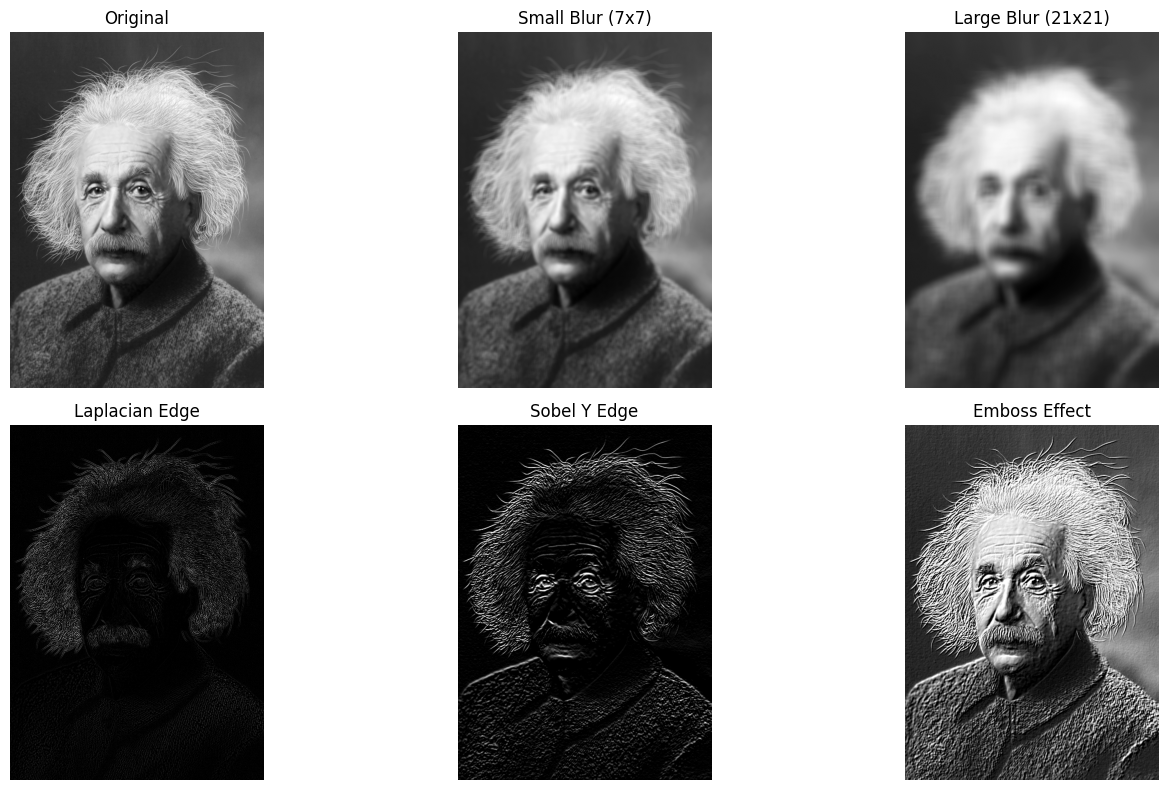

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
image = cv2.imread('/content/ein3.jpg', cv2.IMREAD_GRAYSCALE)

# Define kernels with descriptions

# 1. Average Blur (Small 7x7 kernel) - smooths image by averaging local pixels
smallBlur = np.ones((7, 7), dtype="float") * (1.0 / (7 * 7))

# 2. Average Blur (Large 21x21 kernel) - stronger smoothing effect
largeBlur = np.ones((21, 21), dtype="float") * (1.0 / (21 * 21))

# 3. Laplacian Kernel - detects edges by approximating second derivatives
laplacian = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype="int")

# 4. Sobel Y-Axis Kernel - detects vertical edges by gradient along y-axis
sobelY = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype="int")

# 5. Emboss Kernel - produces an embossing effect by highlighting edges with a 3D look
emboss = np.array([
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
], dtype="int")

# Apply convolutions
small_blurred = cv2.filter2D(image, -1, smallBlur)
large_blurred = cv2.filter2D(image, -1, largeBlur)
laplacian_edge = cv2.filter2D(image, -1, laplacian)
sobel_y_edge = cv2.filter2D(image, -1, sobelY)
embossed = cv2.filter2D(image, -1, emboss)

# Plot results for comparison
titles = [
    'Original', 'Small Blur (7x7)', 'Large Blur (21x21)',
    'Laplacian Edge', 'Sobel Y Edge', 'Emboss Effect'
]
images = [
    image, small_blurred, large_blurred, laplacian_edge, sobel_y_edge, embossed
]

plt.figure(figsize=(15, 8))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Traditionally, image processing operations such as smoothing, sharpening, and edge detection rely on manually defined kernels (filters). **Each kernel is designed to perform a specific function on images by sliding over the pixels and applying mathematical operations.**

### CNN: An algorithm automates image processing

What if instead of manually creating these filters, we let a machine learning model **learn** the optimal filters automatically based on the data? This idea is at the heart of **Convolutional Neural Networks (CNNs)**.

- CNNs learn filters through a combination of convolutional layers, nonlinear activation functions (like ReLU), pooling layers, and backpropagation.

**How do CNNs achieve this?**

The answer lies in the careful stacking of different layer types, each contributing to extracting and refining features throughout the network.

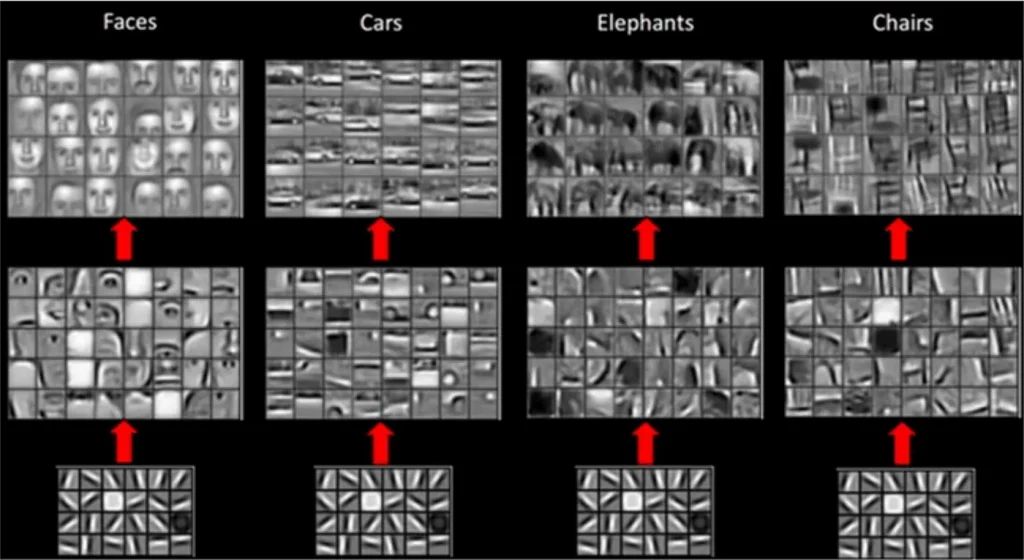

## Introduction to CNN

### Traditional Feedforward Neural Networks (ANNs)

- In ANNs, **every neuron in one layer is connected to every neuron in the next layer.**
- This structure is called a **fully connected (FC) layer**, where each input feature influences all outputs.
- These **fully connected layers dominate the network**, especially in early classical designs.

### What is Convolutional Neural Networks (CNNs)?

- CNNs introduce a specialized layer called the **convolutional layer that replaces fully connected layers for feature extraction**.
- In CNNs, the early layers apply **convolutions**, which scan the input with filters (kernels) to **detect local patterns like edges or textures**.
- Each layer applies numerous filters — often hundreds or thousands — that extract and combine features from the input. These combined outputs are then passed to the next layer. During training, **CNNs automatically learn the optimal values of these filters**.
- After convolution, a **nonlinear activation function** (typically ReLU) is applied to add nonlinearity. The **repeated process of convolution** plus activation continues through **multiple layers**.
- CNNs also include other layer types such as **pooling layers**, which **reduce spatial dimensions** (width and height) to **reduce computational load** and **mitigate overfitting**.
- Fully connected layers appear only near the **end of the network**, where extracted features are used to make final classification decisions.

### Why Convolutional Neural Networks?

**Automatic learning of image processing operations** in Convolutional Neural Networks (CNNs) **is a key innovation** that distinguishes them from traditional approaches relying on manually designed filters.

**In CNNs:**

- Each convolutional layer contains **multiple small filters (kernels)** that are initially assigned random values.
  - During training, the network **learns the optimal values** of these filters by minimizing prediction error on the given training data.
  - **Early layers learn to detect simple, low-level features such as edges** and textures directly from raw pixel values.
  - As we move deeper into the network, **subsequent layers automatically compose these low-level features into more abstract and complex patterns** like shapes, object parts, or semantic concepts.
- This learning process **replaces the need for human-designed image processing filters like blurring or edge detection kernels**.
- **Through backpropagation, the CNN adjusts all the filter values** to optimally extract features beneficial to the network’s ultimate task (e.g., classification).
  
Thus, CNNs **autonomously discover powerful image transformations and feature extractors** that adapt to the data and task, enabling superior performance on object recognition, detection, and other computer vision problems.

### What are the advantages of CNNs over ANNs?

- **Local connectivity:** Convolutions focus on **spatially local information**, unlike ANNs where every input connects globally.
- **Parameter efficiency:** Sharing filter weights across spatial locations **drastically reduces the total parameters** compared to fully connected layers.
- **Compositionality:** Each filter composes lower-level features into higher-level representations, akin to mathematical function composition $ f(g(h(x))) $. This hierarchical feature learning—from pixels to edges to shapes to complex objects—happens naturally during training, enabling CNNs to extract rich and meaningful representations.
- **Spatial hierarchy:** CNNs **preserve spatial structure**, learning **hierarchical patterns from pixels to edges to objects**. The process typically proceeds as follows:
  - The **first convolutional layer** learns to detect **simple features such as edges using raw pixel data**.
  - Subsequent layers use those **edges to identify more complex patterns** like shapes or “blobs.”
  - Higher layers combine these shapes into even **more abstract features such as facial components** or parts of objects.
  - Finally, the last layer uses these **sophisticated features to classify the image content**.
- **Suitability:** CNNs are particularly powerful for image, video, and spatial data, where **locality and translation invariance are important**.
  - **Local invariance:** Pooling layers summarize regions exhibiting strong responses to filters, CNNs can effectively recognize objects regardless of where they appear in an image.

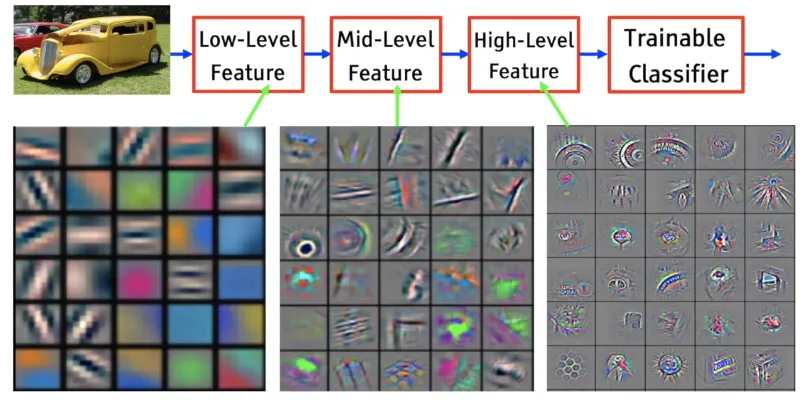

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten
from keras.models import Model, Sequential

In [ ]:
# Load sample image
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [ ]:
rand_img_idx = np.random.choice((np.arange(0, 60000)), 10)
rand_img_idx

array([27709, 34824, 59869, 23729, 27398, 47527, 15504, 31082, 27489,
        5545])

In [ ]:
image_batch = np.expand_dims(X_train[rand_img_idx], axis = -1)
image_batch.shape

(10, 28, 28, 1)

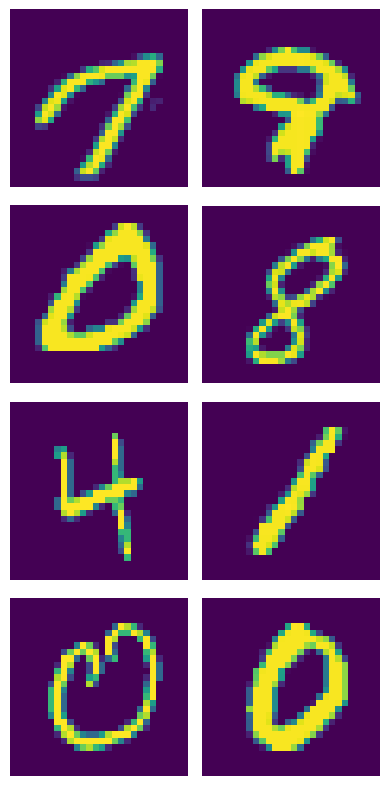

In [ ]:
keras.visualization.plot_image_gallery(image_batch)

In [ ]:
# Build ANN model
model = Sequential([
    Input(shape=(28*28,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define simple CNN model
model = Sequential([
    Conv2D(4, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)),
    # MaxPooling2D(pool_size=(2,2)),
    Conv2D(8, kernel_size=(3,3), activation='relu'),
    # MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(1000, activation = 'relu'),
    Dense(10, activation = 'softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1000)           │     4,609,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,619,346 (17.62 MB)

 Trainable params: 4,619,346 (17.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rand_img_idx = np.random.choice((np.arange(0, 60000)), 1)[0]
rand_img_idx

np.int64(8759)

In [ ]:
# Normalize and expand dims to have shape (batch, height, width, channels)
x_sample = X_train[rand_img_idx].astype('float32') / 255.0
x_sample = np.expand_dims(x_sample, axis=0)   # batch dimension
x_sample = np.expand_dims(x_sample, axis=-1)  # channel dimension (grayscale)
print('Input image shape:', x_sample.shape)  # (1, 28, 28, 1)

Input image shape: (1, 28, 28, 1)


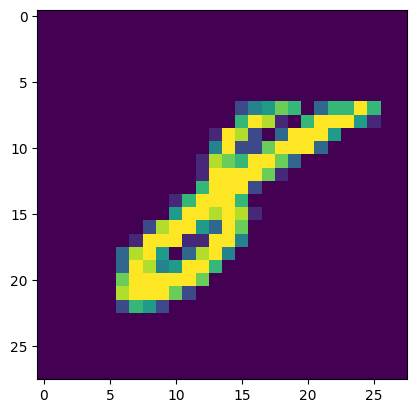

In [ ]:
# Visualize the input image
plt.imshow(x_sample.squeeze())

In [ ]:
# Get output feature maps by running the input image through the model
feature_maps = model.predict(x_sample)
print('Feature maps shape:', feature_maps.shape)  # (1, 11, 11, 8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Feature maps shape: (1, 11, 11, 8)


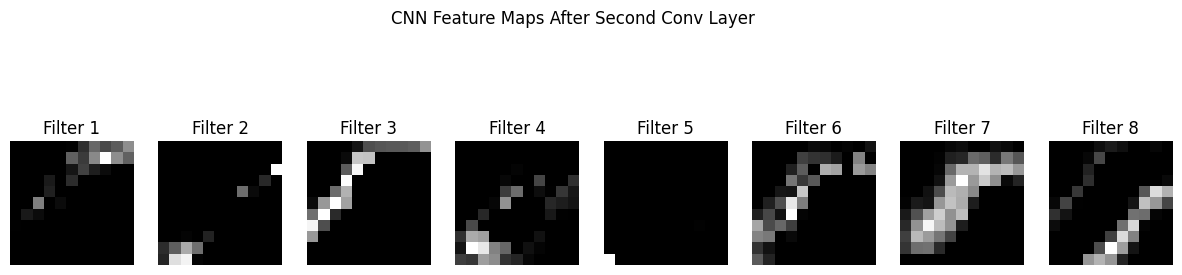

In [ ]:
# Visualize the 8 feature maps from second Conv layer
fig, axs = plt.subplots(1, 8, figsize=(15, 4))
for i in range(8):
    axs[i].imshow(feature_maps[0, :, :, i], cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f'Filter {i+1}')
plt.suptitle('CNN Feature Maps After Second Conv Layer')
plt.show()

## Layers of CNN

CNNs are composed of several types of layers, each playing a unique role in the network. The most commonly encountered layers include:

- **Convolutional Layer:**  
  The core layer that applies multiple small filters (kernels) to the input volume to extract spatial features like edges, textures, and shapes. These filters slide over the input and produce feature maps.

- **Activation Layer:**  
  Adds non-linearity to the network by applying element-wise functions such as the Rectified Linear Unit (ReLU), enabling the network to learn complex patterns beyond linear combinations.

- **Pooling Layer:**  
  Reduces the spatial dimensions (width and height) of the feature maps, which lowers computational load and helps prevent overfitting. Common types include max pooling and average pooling.

- **Fully Connected Layer:**  
  Located near the network’s end, these layers flatten the feature maps and connect every neuron to every neuron in the next layer. They integrate extracted features to perform classification or regression.

- **Batch Normalization:**  
  Normalizes layer inputs to stabilize learning and accelerate training.

- **Dropout:**  
  A regularization layer that randomly deactivates a subset of neurons during training to reduce overfitting.

**Layer Stacking in CNNs**

CNNs are typically represented as sequences of layers. A simple example:

```
INPUT => CONV => RELU => FC => SOFTMAX
```

Here, the network:
- Accepts an input image.
- Applies convolution filters.
- Passes the result through a ReLU activation layer.
- Feeds the output to fully connected layers.
- Ends with a softmax layer (sometimes implicit) to produce classification probabilities.

#### Layer Parameters



- **Learnable parameters:**  
  Only CONV, FC, and to some extent BN layers have parameters learned during training.

- **Non-learnable operations:**  
  Activation (ReLU) and Dropout are considered functional operations rather than layers with parameters but are essential for performance and clarity in network diagrams.

- **Core set for architecture design:**  
  CONV, POOL, RELU, and FC layers are fundamental in defining CNN architectures. Others support or regularize but are secondary in architecture blueprinting.

- **Activation inclusion:**  
  Activations are typically present after convolutional and fully connected layers; sometimes omitted from diagrams for simplicity but always implicitly applied.

### Input and output layers

Unlike a traditional neural network where layers are arranged as 2D matrices, the layers in a CNN are structured as **3D volumes**. These dimensions are:

- **Width** (spatial dimension)
- **Height** (spatial dimension)
- **Depth** (the third dimension, such as the number of channels in the input image or the number of filters in a convolutional layer)

This 3D volume structure allows CNNs to process the spatial and depth-wise patterns present in images.

#### Local Connectivity

In CNNs, each neuron in a given layer connects only to a **small local region** of the previous layer, rather than connecting fully to every neuron. This is known as **local connectivity**.

Benefits of local connectivity:

- Significant reduction in the number of parameters compared to fully connected neural networks.
- Allows the network to focus on localized patterns (such as edges or textures).
- Preserves spatial hierarchy and structure in images.

#### The Output Layer Structure

The final output of a CNN is typically a volume with spatial dimensions reduced to $1 \times 1$ and depth $N$, where $N$ corresponds to the number of classes or outputs.

In [ ]:
import keras
from keras import layers, models

# Define a simple CNN model for MNIST (28x28 grayscale)
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),                  # Input 3D volume: 28x28x1
    layers.Conv2D(8, kernel_size=3, activation='relu'), # Output volume 26x26x8
    layers.MaxPooling2D(pool_size=2),                  # Output volume 13x13x8
    layers.Conv2D(16, kernel_size=3, activation='relu'), # Output volume 11x11x16
    layers.MaxPooling2D(pool_size=2),                  # Output volume 5x5x16
    layers.Flatten(),                                  # Flatten to 400
    layers.Dense(10, activation='softmax')            # Final output vector (class scores)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,258 (20.54 KB)

 Trainable params: 5,258 (20.54 KB)

 Non-trainable params: 0 (0.00 B)

### Convolution layer

These are thecore components of Convolutional Neural Networks (CNNs). **Each CONV layer contains \(K\) learnable filters (kernels)**, typically square in shape but small spatially, that extend through the entire depth of the input volume.
- For the input image, the depth equals the number of channels (e.g., 3 for RGB).
- Deeper in the network, the depth corresponds to the number of filters from the previous layer.

In [ ]:
# Example parameters
input_width, input_height, input_depth = 28, 28, 1  # MNIST input - Grayscale
receptive_field = 3  # F = 3 (kernel/filter size 3x3)

# Weights (connections) for a neuron in first conv layer
connections_first_layer = receptive_field * receptive_field * input_depth
print(f'Connections per neuron (first layer): {connections_first_layer}')

Connections per neuron (first layer): 9


During the forward pass, each of the \(K\) (assume K = 8) filters slides (convolves) across the width and height of the input volume (eg: 28x28x1), performing element-wise multiplications and summations at every spatial position. This process produces \(K\), 2D **activation maps** (8 activation maps), which are then stacked along the depth dimension to form the output volume.

In [ ]:
# Deeper layer volume size
deep_width, deep_height, deep_depth = 26, 26, 8  # smaller spatial, greater depth

# Connections for neuron deeper in the network
connections_deep_layer = receptive_field * receptive_field * deep_depth
print(f'Connections per neuron (deep layer): {connections_deep_layer}')

Connections per neuron (deep layer): 72


Each output entry corresponds to a **neuron activated by a local feature within its receptive field**—and the network “learns” filters that respond to specific patterns at different spatial locations.

- In early layers, filters detect low-level features like edges or corners, while deeper layers capture higher-level features, such as parts of objects (faces, paws, car hoods).
  - This mirrors the neuron activation concept where neurons are becoming `excited` and `activating` when they see a particular pattern in an input image.

A key characteristic of CNNs is local connectivity through the receptive field \(F\), the small spatial region that each neuron looks at in the input volume.

- The receptive field size \(F\) corresponds to the filter size $(F \times F)$ convolved over the input volume.
  - This local connection reduces the number of parameters compared to full connectivity.
  - For example, in a MNIST input of size $(28 \times 28 \times 1)$, a neuron with a $(3 \times 3)$ receptive field connects to $(3 \times 3 \times 1 = 9)$ weights.
  - In a deeper volume sized $(11 \times 11 \times 16)$, each neuron with the same receptive field connects to $(3 \times 3  \times 8 \times 16 = 1152)$ weights.
- The final output volume size is determined by three parameters:
  - depth (number of filters),
  - stride (step size of sliding filters), and
  - zero-padding (padding around input borders).

#### Depth

The **depth** of an output volume in a convolutional layer governs the number of filters—or neurons—that connect to each local region of the input volume.
- In MNIST example number of Receptive fields or kernels considered in the first layer are 8. The depth of the second layer becomes 8
- Each filter produces its **own 2D activation map, which responds selectively to specific features** like oriented edges, blobs, or colors.
- Thus, the **depth of the activation volume equals \(K\), the number of filters** being learned in that layer.
- The collection of filters examining the same $(x,y)$ spatial location across the input is called a **depth column**.
- Essentially, at each spatial position, the **depth column represents the activations generated by all filters** for that local receptive field.

In [ ]:
# Number of filters (depth) in the current convolutional layer
num_filters = 8

# Each filter produces an activation map
activation_maps = [np.random.rand(28, 28) for _ in range(num_filters)]

# Stack activation maps depth-wise to form output volume of shape (28, 28, num_filters)
output_volume = np.stack(activation_maps, axis=-1)

print('Output volume shape:', output_volume.shape)  # (28, 28, 8)

# At a spatial position (x,y), activations from all filters form a depth column
x, y = 10, 15
depth_column = output_volume[x, y, :]  # shape (num_filters,)
print('Depth column activations at (10,15):', depth_column)

Output volume shape: (28, 28, 8)
Depth column activations at (10,15): [0.76999355 0.78634501 0.98466974 0.43272914 0.75673017 0.04157896
 0.39363552 0.0169128 ]


#### Stride

Stride is the **step size by which a convolutional filter (kernel) moves across the input image or volume during the convolution operation.**
- Instead of moving one pixel at a time, as in the basic sliding-window operation, stride \(S\) specifies **how many pixels the filter skips after each step horizontally and vertically.**
  - With stride $S=1$, the filter moves one pixel each time, producing a **larger output volume** with overlapping receptive fields.
  - With stride $S=2$, the filter moves two pixels per step—skipping intermediate positions—yielding a **smaller output volume** and less overlap among receptive fields.
  - **Adjusting stride** thus **controls the spatial reduction of the input**; higher strides downsample the input more aggressively.

This concept can be illustrated by sliding a $3 \times 3$ kernel over a $5 \times 5$ input.
- At stride 1, the filter produces a large output by sliding pixel by pixel
- At stride 2, it produces a smaller output because it jumps two pixels at a time.
- Stride is a crucial hyperparameter that **balances feature extraction detail and computational efficiency**
  - smaller strides keep **more spatial detail but increase computation**,
  - larger strides **reduce input size and computation** but may lose fine details.

In [ ]:
import numpy as np

def conv_output_size(input_size, kernel_size, stride, padding=0):
    return ((input_size - kernel_size + 2 * padding) // stride) + 1

input_size = 28
kernel_size = 3

stride_1 = 1
stride_2 = 2

output_size_stride_1 = conv_output_size(input_size, kernel_size, stride_1)
output_size_stride_2 = conv_output_size(input_size, kernel_size, stride_2)

print(f"Output size with stride {stride_1}: {output_size_stride_1} x {output_size_stride_1}")
print(f"Output size with stride {stride_2}: {output_size_stride_2} x {output_size_stride_2}")

Output size with stride 1: 26 x 26
Output size with stride 2: 13 x 13


#### Padding

- Padding refers to **adding extra pixels around the borders of an input image or feature map**.
  - The most common padding **value is zero**.
- Applying a filter to an input image or the output feature map of a previous convolutional layer results in the **generated feature map being smaller than the input.**
- **With multiple convolutional layers**, the feature maps progressively shrink, risking **information loss at the borders**.
- To prevent this, padding is applied to the input image or feature map, **preserving spatial dimensions and retaining edge information**.

Padding is used in convolutional layers **to preserve the spatial dimensions of the input after convolution.**
- By adding zeros around the border of the input—called **zero-padding and controlled by the parameter \(P\)**—the **output volume can maintain the same width and height as the input volume.**

- This is crucial in deep CNNs, where **multiple convolution layers are stacked and without padding**, the spatial size would shrink too quickly, **limiting the network’s ability to learn meaningful features**.

- Applying a $3 \times 3$ kernel to a $5 \times 5$ input with stride $S=1$ and no padding results in a smaller output $3 \times 3$.
- But if we pad with one zero layer around the input $P=1$ creating a $(7 \times 7)$ volume, the output after convolution matches the original input size $(5 \times 5)$.

- The output size $W_{\text{output}}$ for square inputs can be computed as:  
$$
W_{\text{output}} = \frac{W_{\text{input}} - F + 2P}{S} + 1
$$  
    where
- $W_{\text{input}}$ is input width,
- \(F\) is the filter size,
- \(P\) is zero-padding, and
- \(S\) is stride.
- $W_{\text{output}}$ must be an integer to properly tile the neurons across the volume.

#### Convolution Layer parameters and output size

- Inputs: $W_{\text{input}} \times H_{\text{input}} \times D_{\text{input}}$ -  (width, height, depth)
- Parameters:  
  1. Number of filters \(K\) (output depth)  
  2. Receptive field size \(F\) (kernel size)  
  3. Stride \(S\)  
  4. Padding \(P\)  
- Output size:  
$$
W_{\text{output}} = H_{\text{output}} = \frac{W_{\text{input}} - F + 2P}{S} + 1,
$$

$$
\quad D_{\text{output}} = K
$$

In [ ]:
def conv_output_size(W_input, F, P, S):
    return (W_input - F + 2 * P) // S + 1

# Example parameters (AlexNet first layer example)
W_input = 227  # Corrected input size
F = 11         # Kernel size
P = 0          # No padding
S = 4          # Stride

W_output = conv_output_size(W_input, F, P, S)
print(f'Output spatial size: {W_output} x {W_output}')  # 55 x 55

Output spatial size: 55 x 55


### Activation layer

Activation layers follow each convolutional layer in CNNs to apply nonlinear activation functions like ReLU, ELU, or Leaky ReLU variants. These layers introduce nonlinearity essential for learning complex patterns.
- Though called layers, activation layers do not have parameters or weights to learn .
- Activation functions operate element-wise on the input volume of size $W_{\text{input}} \times H_{\text{input}} \times D_{\text{input}}$, producing an output volume of the exact same dimensions since they do not modify the spatial or depth size.

### Pooling layer

Pooling layers are essential in CNNs **to reduce the spatial dimensions (width and height)** of the input volume.
- Convolutional layers with **stride greater than one, pooling layers** downsample feature maps, reducing parameters and computational cost, while helping control overfitting.
- Commonly, pooling layers are inserted between activation and convolution layers in architectures like:

$$
INPUT => CONV => RELU => POOL => CONV => RELU => POOL => FC.
$$

Pooling operates independently on each depth slice of the input, applying either max or average functions.
- Max pooling is typically used mid-network to reduce spatial size, while average pooling often appears at the network's end to avoid fully connected layers.
- The most common pool size is $2 \times 2$, with stride usually 1 or 2, though larger inputs may use $3 \times 3$ pools early on.
- Types of models
  - **Overlapping pooling**: $F=3, S=2$, applied to large spatial inputs.  
  - **Non-overlapping pooling**: $F=2, S=2$, most common for smaller spatial inputs.  
  - Sometimes \(F=2, S=1\) for smaller images in early layers.

#### Pooling parameters and output size

- Input volume size: $W_{input} \times H_{input} \times D_{input}$  
- Pool size (receptive field): $F \times F$
- Stride: S  
- Output volume size:  
$$
W_{output} = \frac{W_{input} - F}{S} + 1,
$$
$$
\quad H_{output} = \frac{H_{input} - F}{S} + 1,
$$
$$
\quad D_{output} = D_{input}
$$

### Fully Connected Layers

These layers are always positioned at the network’s end typically, one or two FC layers precede the final softmax classifier to produce class probability predictions.

- Fully-connected layers enables high-level reasoning and decision-making based on the **features extracted by convolutional and pooling stages**.

- This design leverages the strength of FC layers to integrate spatially processed features into a global context essential for classification or regression tasks.
- Fully-connected layers thus serve as the final stage in CNNs, transforming extracted features into actionable predictions.

### Batch Normalization

Batch Normalization (BN), is a technique to **normalize activations within mini-batches** during training to  **accelerate training by reducing internal covariate shift**.
- BN significantly **speeds up training** and stabilizes it, permitting higher learning rates and **reducing sensitivity to hyperparameter choices**.
- Although **computation per training step increases**, overall training requires fewer epochs, often resulting in **lower final loss and better generalization**.

- Given a mini-batch of activations $x$, BN normalizes each activation by subtracting the batch mean and dividing by the batch standard deviation, **ensuring outputs have near zero mean and unit variance.**
$$
\hat{x}_i = \frac{x_i - \mu_\text{batch}}{\sqrt{\sigma^2_\text{batch} + \epsilon}}
$$

    where $\mu_\text{batch}$ and $\sigma^2_\text{batch}$ are the mini-batch mean and variance.
- During testing, batch statistics are replaced by **running averages computed during training**, allowing consistent predictions independent of mini-batch variations.
- In the original paper BN layer is placed before the activation function (e.g., ReLU). However, it has been found effective to apply BN **after** the activation.
- Normalizing **after ReLU avoids mixing negative values (which ReLU would zero out) in the normalization step**, leading to better statistical alignment of features passed to subsequent layers, and thus improved accuracy and reduced loss in most cases.

### Dropout layer

Dropout is **a regularization technique** that randomly disconnects a subset of neurons during training, with the **intent of preventing overfitting.**
  - By `dropping out` neurons with a probability $ p $, it ensures that **no single node becomes overly responsible for specific features**, fostering the development of redundant, robust representations.
  - This process effectively trains an ensemble of smaller networks, enhancing generalization to unseen data.
- Dropout is typically applied to fully connected (FC) layers—inserting dropout layers between FC layers in architectures.
- It can also be applied with smaller probabilities in earlier layers following downsampling.
- While dropout may slightly slow down the training process (since fewer neurons are active per pass), **it generally improves test accuracy and reduces overfitting, making models more reliable.**

### CNN: Translational Invariance

- Convolutional Neural Networks (CNNs) are **not inherently invariant to rotation or scaling**, but they **exhibit strong translation invariance due to the convolution and pooling operations**.

- Individual **CNN filters respond to specific orientations and scales**—they are not rotation or scale invariant themselves.
  - Full **CNN learns a collection of filters that activate for various rotated or scaled versions** of a pattern present in the training data, allowing it to recognize these variants. **If training data includes only limited rotations or scales, the CNN is only invariant within those ranges.**

- Translation invariance is **a natural result of filters sliding across all spatial locations and pooling operations** selecting the strongest responses, making the network **less sensitive to exact positions of features**.
  - CNNs handle **translation effectively but require training strategies, data augmentation, or specialized architectures** for true rotation and scale invariance.

In [ ]:
import tensorflow as tf
import keras
from keras import layers, models

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize input images to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
# Define a simple CNN architecture
model = models.Sequential([
    layers.Conv2D(10, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    # layers.MaxPooling2D((2, 2)),

    layers.Conv2D(20, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 30, 30, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 20)     │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 64)     │        11,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 604,222 (2.30 MB)

 Trainable params: 604,222 (2.30 MB)

 Non-trainable params: 0 (0.00 B)